In [2]:
import os
import shutil
import json

# Define your base directory containing train, test, and valid folders
base_dir = 'data'  # Update this with your base directory path

# Iterate over 'train', 'test', and 'valid' directories
for dataset_type in ['train', 'test', 'valid']:
    dataset_path = os.path.join(base_dir, dataset_type)
    
    # Create 'tumor' and 'no_tumor' folders inside the dataset directory
    for category_name in ['tumor', 'no_tumor']:
        category_path = os.path.join(dataset_path, category_name)
        os.makedirs(category_path, exist_ok=True)
    
    # Read the COCO JSON file
    json_path = os.path.join(dataset_path, '_annotations.coco.json')  # Update if your JSON file has a different name
    
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            coco_data = json.load(f)
        
        # Create mappings
        image_id_to_filename = {image['id']: image['file_name'] for image in coco_data['images']}
        category_id_to_name = {category['id']: category['name'] for category in coco_data['categories']}
        image_id_to_category_ids = {}
        
        # Map image IDs to category IDs
        for annotation in coco_data['annotations']:
            image_id = annotation['image_id']
            category_id = annotation['category_id']
            if image_id not in image_id_to_category_ids:
                image_id_to_category_ids[image_id] = set()
            image_id_to_category_ids[image_id].add(category_id)
        
        # Debug: Print category mapping
        print("Category ID to Name Mapping:")
        for cid, cname in category_id_to_name.items():
            print(f"  ID: {cid}, Name: {cname}")
        
        # Define the mapping based on your categories
        tumor_category_ids = set()
        no_tumor_category_ids = set()
        
        for category_id, category_name in category_id_to_name.items():
            if category_name == '1':
                tumor_category_ids.add(category_id)
            elif category_name == '0':
                no_tumor_category_ids.add(category_id)
            else:
                # Handle other categories if necessary
                pass
        
        # If no categories found, print an error and continue
        if not tumor_category_ids and not no_tumor_category_ids:
            print(f"No 'tumor' or 'no_tumor' categories found in {dataset_type}. Please check your JSON.")
            continue  # Skip this dataset_type
        
        # Determine label for each image
        image_labels = {}
        for image_id, filename in image_id_to_filename.items():
            category_ids = image_id_to_category_ids.get(image_id, set())
            
            # Check if any of the category IDs for this image correspond to 'tumor'
            if any(cid in tumor_category_ids for cid in category_ids):
                image_labels[filename] = 'tumor'
            elif any(cid in no_tumor_category_ids for cid in category_ids):
                image_labels[filename] = 'no_tumor'
            else:
                # If the image doesn't match 'tumor' or 'no_tumor', handle accordingly
                image_labels[filename] = 'no_tumor'  # Default to 'no_tumor' if uncertain
            
        # Debug: Print total images to be processed
        print(f"Processing {len(image_labels)} images in {dataset_type}...")
        
        # Move images based on their label
        for filename, label in image_labels.items():
            image_path = os.path.join(dataset_path, filename)
            dest_folder = os.path.join(dataset_path, label)
            dest_path = os.path.join(dest_folder, filename)
            
            # Debug:
            if os.path.exists(image_path):
                try:
                    shutil.move(image_path, dest_path)
                    print(f"Moved: {filename} -> {label}")
                except Exception as e:
                    print(f"Error moving {filename}: {e}")
            else:
                print(f"Image not found: {filename}")
        
        print(f"Completed organizing images in {dataset_type}.")
    else:
        print(f"JSON file not found in {dataset_type}. Skipping...")

print("Dataset organization completed.")


Category ID to Name Mapping:
  ID: 0, Name: Tumor
  ID: 1, Name: 0
  ID: 2, Name: 1
Processing 1502 images in train...
Moved: 2256_jpg.rf.3afd7903eaf3f3c5aa8da4bbb928bc19.jpg -> no_tumor
Moved: 2871_jpg.rf.3b6eadfbb369abc2b3bcb52b406b74f2.jpg -> no_tumor
Moved: 2921_jpg.rf.3b952f91f27a6248091e7601c22323ad.jpg -> no_tumor
Moved: 2777_jpg.rf.3b60ea7f7e70552e70e41528052018bd.jpg -> no_tumor
Moved: 2860_jpg.rf.3bb87fa4f938af5abfb1e17676ec1dad.jpg -> no_tumor
Moved: 2161_jpg.rf.3be4125d1ffe011c0ed462d9fe0d2152.jpg -> no_tumor
Moved: 2265_jpg.rf.3c62c7b8825039fab853256f9a9fe141.jpg -> no_tumor
Moved: 1491_jpg.rf.3c658e83538de0fa5a3f4e13d7d85f12.jpg -> tumor
Moved: 1385_jpg.rf.3c67cb92e2922dba0e6dba86f69df40b.jpg -> tumor
Moved: 2534_jpg.rf.3c8c86666860368d46b8f7bcd95ac220.jpg -> no_tumor
Moved: 2433_jpg.rf.3cdf8e4cb3a08e9b2fccc6c6082c2344.jpg -> no_tumor
Moved: 1550_jpg.rf.3d067be9580ec32dbee5a89c675d8459.jpg -> tumor
Moved: 2076_jpg.rf.3d43cf72261974fe3f574590e781b8f4.jpg -> no_tumor
Moved:

In [3]:
pip install torch torchvision torchsummary


Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchsummary import summary
import timm


In [10]:
# Parameters
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 2  # 'tumor' and 'no_tumor'
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4


In [11]:
# Data augmentation and normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],  # Mean for ImageNet
                             [0.229, 0.224, 0.225])  # Std for ImageNet
    ]),
    'valid': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


In [12]:
data_dir = 'data'  # Update with your dataset path

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'valid', 'test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=4)
               for x in ['train', 'valid', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')
print(f'Classes: {class_names}')


Using device: cpu
Classes: ['no_tumor', 'tumor']


In [13]:
dataset_sizes

{'train': 1502, 'valid': 429, 'test': 215}

In [29]:
# Load pre-trained MobileNetV2 from torchvision
mobilenet = models.mobilenet_v2(pretrained=True)

# Load pre-trained ViT from timm
vit = timm.create_model('vit_base_patch16_224', pretrained=True)

C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [30]:
print(mobilenet)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [31]:
print(vit)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [32]:
# Freeze all layers in MobileNet
for param in mobilenet.parameters():
    param.requires_grad = False

# Freeze all layers in ViT
for param in vit.parameters():
    param.requires_grad = False

In [33]:
# Remove the classification head from ViT
vit.reset_classifier(0)  # This effectively removes the classifier head

In [45]:
class HybridModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(HybridModel, self).__init__()
        self.mobilenet_features = mobilenet.features  # MobileNet feature extractor
        self.vit = vit  # ViT model without classification head

        # Define the classifier
        self.classifier = nn.Sequential(
            nn.Linear(1280 + vit.num_features, 512),  # Concatenated features
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # MobileNet features
        x_mobile = self.mobilenet_features(x)  # Corrected line
        x_mobile = nn.functional.adaptive_avg_pool2d(x_mobile, (1, 1))
        x_mobile = x_mobile.view(x_mobile.size(0), -1)  # Shape: [batch_size, 1280]

        # ViT features
        x_vit = self.vit(x)  # Shape: [batch_size, vit.num_features]

        # Concatenate features
        x = torch.cat((x_mobile, x_vit), dim=1)  # Shape: [batch_size, 1280 + vit.num_features]

        # Classification
        x = self.classifier(x)
        return x


In [46]:
model = HybridModel()
model = model.to(device)


In [47]:
criterion = nn.CrossEntropyLoss()

In [48]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)


In [49]:
def train_model(model, criterion, optimizer, dataloaders, dataset_sizes, num_epochs=25):
    best_model_wts = model.state_dict()
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward pass and optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            # Compute epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Deep copy the model
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
        
        print()
    
    print(f'Best validation Acc: {best_acc:.4f}')
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model


In [50]:
model = train_model(model, criterion, optimizer, dataloaders, dataset_sizes, num_epochs=NUM_EPOCHS)


Epoch 1/20
----------
train Loss: 0.3483 Acc: 0.8462
valid Loss: 0.2481 Acc: 0.8788

Epoch 2/20
----------
train Loss: 0.1812 Acc: 0.9348
valid Loss: 0.1719 Acc: 0.9277

Epoch 3/20
----------
train Loss: 0.1603 Acc: 0.9421
valid Loss: 0.1472 Acc: 0.9301

Epoch 4/20
----------
train Loss: 0.1210 Acc: 0.9634
valid Loss: 0.1281 Acc: 0.9417

Epoch 5/20
----------
train Loss: 0.1170 Acc: 0.9554
valid Loss: 0.1165 Acc: 0.9464

Epoch 6/20
----------
train Loss: 0.0937 Acc: 0.9720
valid Loss: 0.1190 Acc: 0.9580

Epoch 7/20
----------
train Loss: 0.1075 Acc: 0.9694
valid Loss: 0.1241 Acc: 0.9487

Epoch 8/20
----------
train Loss: 0.0915 Acc: 0.9694
valid Loss: 0.0988 Acc: 0.9650

Epoch 9/20
----------
train Loss: 0.0836 Acc: 0.9734
valid Loss: 0.0983 Acc: 0.9580

Epoch 10/20
----------
train Loss: 0.0759 Acc: 0.9780
valid Loss: 0.1160 Acc: 0.9627

Epoch 11/20
----------
train Loss: 0.0858 Acc: 0.9707
valid Loss: 0.0867 Acc: 0.9650

Epoch 12/20
----------
train Loss: 0.0722 Acc: 0.9727
valid Los

In [51]:
def test_model(model, dataloader, dataset_size):
    model.eval()
    running_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            running_corrects += torch.sum(preds == labels.data)
    
    test_acc = running_corrects.double() / dataset_size
    print(f'Test Accuracy: {test_acc:.4f}')


In [52]:
test_model(model, dataloaders, dataset_sizes['test'])

Test Accuracy: 0.9814


In [53]:
torch.save(model.state_dict(), 'hybrid_model.pth')


In [54]:
# Initialize the model architecture
model_1 = HybridModel(num_classes=NUM_CLASSES)
model_1 = model.to(device)

# Load the saved weights
model_1.load_state_dict(torch.load('hybrid_model.pth'))


C:\Users\0871\AppData\Local\Temp\ipykernel_25868\2898916667.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load('hybrid_model.pth'))


<All keys matched successfully>

In [59]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


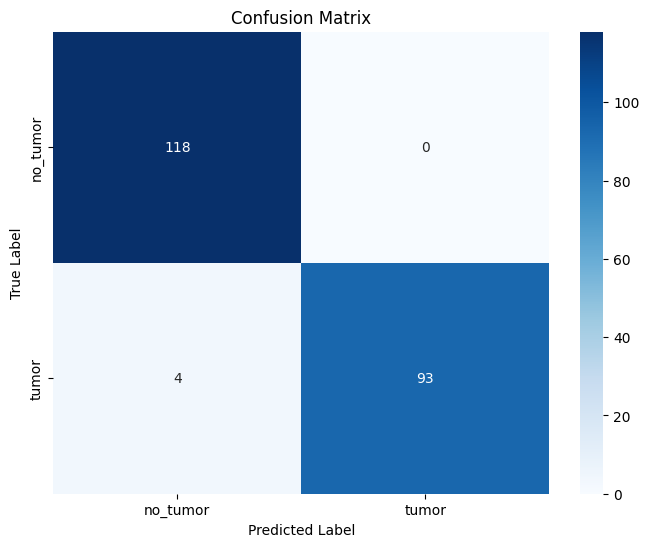

Classification Report:
              precision    recall  f1-score   support

    no_tumor       0.97      1.00      0.98       118
       tumor       1.00      0.96      0.98        97

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



In [61]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Function to get predictions and true labels
def get_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_preds, all_labels

# Get predictions and true labels for the test set
test_preds, test_labels = get_predictions(model, dataloaders['test'])

# Calculate confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Classification report
report = classification_report(test_labels, test_preds, target_names=class_names)
print('Classification Report:')
print(report)


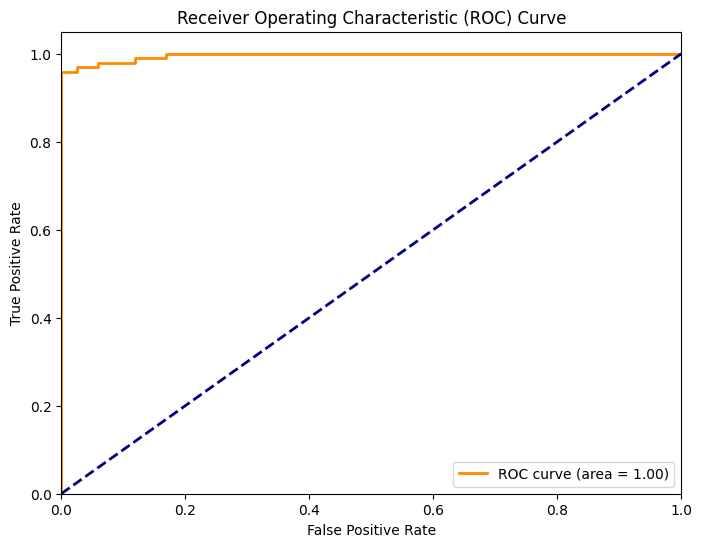

In [62]:
from sklearn.metrics import roc_curve, auc

# Get probabilities instead of predicted classes
def get_probabilities(model, dataloader):
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = nn.functional.softmax(outputs, dim=1)
            all_probs.extend(probs[:,1].cpu().numpy())  # Probability of class '1'
            all_labels.extend(labels.cpu().numpy())
    
    return all_probs, all_labels

# Get probabilities and true labels
test_probs, test_labels = get_probabilities(model, dataloaders['test'])

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange',
         lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


# Mobilenet

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [15]:
from torchvision import datasets, transforms, models

In [16]:

# Load pre-trained MobileNetV2
mobilenet = models.mobilenet_v2(pretrained=True)


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
# Get the input dimension of the classifier
num_ftrs = mobilenet.classifier[1].in_features

# Replace the classifier with a new one
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_ftrs, NUM_CLASSES)
)

# Move the model to the appropriate device
model = mobilenet.to(device)


In [18]:
# Get the input dimension of the classifier
num_ftrs = mobilenet.classifier[1].in_features

# Replace the classifier with a new one
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_ftrs, NUM_CLASSES)
)

# Move the model to the appropriate device
model = mobilenet.to(device)


In [19]:
# Optionally, freeze some layers
for param in model.features.parameters():
    param.requires_grad = False  # Freeze feature extractor layers


In [20]:
criterion = nn.CrossEntropyLoss()


In [21]:
# Only parameters with requires_grad=True will be updated
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)


In [22]:
def train_model(model, criterion, optimizer, dataloaders, dataset_sizes, num_epochs=25):
    best_model_wts = model.state_dict()
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward pass and optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            # Compute epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Deep copy the model
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
        
        print()
    
    print(f'Best validation Acc: {best_acc:.4f}')
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model


In [23]:
model = train_model(model, criterion, optimizer, dataloaders, dataset_sizes, num_epochs=NUM_EPOCHS)


Epoch 1/20
----------
train Loss: 0.6397 Acc: 0.6451
valid Loss: 0.5392 Acc: 0.8135

Epoch 2/20
----------
train Loss: 0.5029 Acc: 0.8229
valid Loss: 0.4692 Acc: 0.8438

Epoch 3/20
----------
train Loss: 0.4145 Acc: 0.8628
valid Loss: 0.4041 Acc: 0.8741

Epoch 4/20
----------
train Loss: 0.3697 Acc: 0.8822
valid Loss: 0.3701 Acc: 0.8881

Epoch 5/20
----------
train Loss: 0.3318 Acc: 0.8901
valid Loss: 0.3367 Acc: 0.8765

Epoch 6/20
----------
train Loss: 0.3021 Acc: 0.8995
valid Loss: 0.3124 Acc: 0.8998

Epoch 7/20
----------
train Loss: 0.2802 Acc: 0.9161
valid Loss: 0.2925 Acc: 0.9044

Epoch 8/20
----------
train Loss: 0.2746 Acc: 0.9061
valid Loss: 0.2895 Acc: 0.9091

Epoch 9/20
----------
train Loss: 0.2491 Acc: 0.9228
valid Loss: 0.2708 Acc: 0.9114

Epoch 10/20
----------
train Loss: 0.2499 Acc: 0.9208
valid Loss: 0.2709 Acc: 0.9138

Epoch 11/20
----------
train Loss: 0.2310 Acc: 0.9228
valid Loss: 0.2544 Acc: 0.9091

Epoch 12/20
----------
train Loss: 0.2362 Acc: 0.9174
valid Los

In [9]:
def test_model(model, dataloader):
    model.eval()
    running_corrects = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            running_corrects += torch.sum(preds == labels.data)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_acc = running_corrects.double() / dataset_sizes['test']
    print(f'Test Accuracy: {test_acc:.4f}')
    
    return all_preds, all_labels


In [ ]:
test_preds, test_labels = test_model(model, dataloaders['test'])


In [26]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Classification report
report = classification_report(test_labels, test_preds, target_names=class_names)


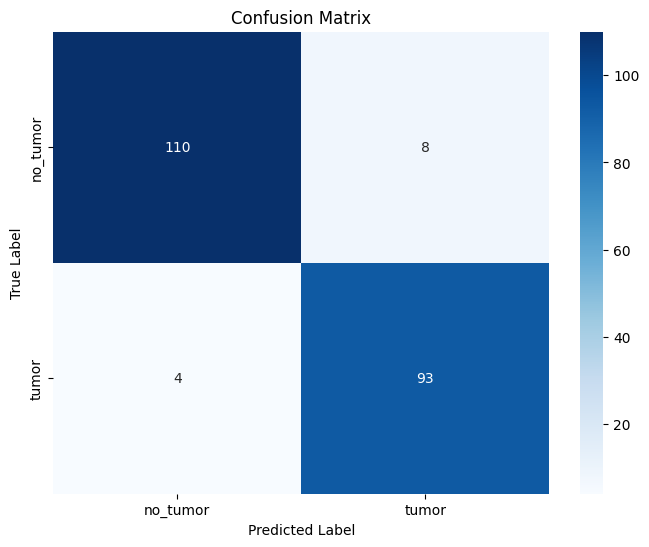

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


In [28]:
print('Classification Report:')
print(report)


Classification Report:
              precision    recall  f1-score   support

    no_tumor       0.96      0.93      0.95       118
       tumor       0.92      0.96      0.94        97

    accuracy                           0.94       215
   macro avg       0.94      0.95      0.94       215
weighted avg       0.95      0.94      0.94       215



In [29]:
torch.save(model.state_dict(), 'mobilenet_model.pth')


In [30]:
# Initialize the model architecture
model = models.mobilenet_v2(pretrained=False)
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_ftrs, NUM_CLASSES)
)
model = model.to(device)

# Load the saved weights
model.load_state_dict(torch.load('mobilenet_model.pth'))


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\0871\AppData\Local\Temp\ipykernel_15696\4077546173.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default val

<All keys matched successfully>

# Densenet

In [31]:
# Load pre-trained DenseNet-121
densenet = models.densenet121(pretrained=True)


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [32]:
# Get the input dimension of the classifier
num_ftrs = densenet.classifier.in_features

# Replace the classifier with a new one
densenet.classifier = nn.Linear(num_ftrs, NUM_CLASSES)

# Move the model to the appropriate device
model = densenet.to(device)



In [33]:
# Optionally, freeze some layers
for param in model.features.parameters():
    param.requires_grad = False  # Freeze feature extractor layers


In [34]:
model = train_model(model, criterion, optimizer, dataloaders, dataset_sizes, num_epochs=NUM_EPOCHS)


Epoch 1/20
----------
train Loss: 0.7403 Acc: 0.4494
valid Loss: 0.7910 Acc: 0.4382

Epoch 2/20
----------
train Loss: 0.7432 Acc: 0.4474
valid Loss: 0.7578 Acc: 0.4289

Epoch 3/20
----------
train Loss: 0.7349 Acc: 0.4527
valid Loss: 0.7559 Acc: 0.4336

Epoch 4/20
----------
train Loss: 0.7347 Acc: 0.4514
valid Loss: 0.7530 Acc: 0.4359

Epoch 5/20
----------
train Loss: 0.7336 Acc: 0.4527
valid Loss: 0.7576 Acc: 0.4289

Epoch 6/20
----------
train Loss: 0.7421 Acc: 0.4427
valid Loss: 0.7542 Acc: 0.4359

Epoch 7/20
----------
train Loss: 0.7360 Acc: 0.4527
valid Loss: 0.7559 Acc: 0.4359

Epoch 8/20
----------
train Loss: 0.7375 Acc: 0.4421
valid Loss: 0.7563 Acc: 0.4312

Epoch 9/20
----------
train Loss: 0.7348 Acc: 0.4634
valid Loss: 0.7561 Acc: 0.4359

Epoch 10/20
----------
train Loss: 0.7381 Acc: 0.4434
valid Loss: 0.7568 Acc: 0.4359

Epoch 11/20
----------
train Loss: 0.7328 Acc: 0.4587
valid Loss: 0.7550 Acc: 0.4149

Epoch 12/20
----------
train Loss: 0.7336 Acc: 0.4541
valid Los

In [35]:
test_preds, test_labels = test_model(model, dataloaders['test'])


Test Accuracy: 0.5023


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Classification report
report = classification_report(test_labels, test_preds, target_names=class_names)


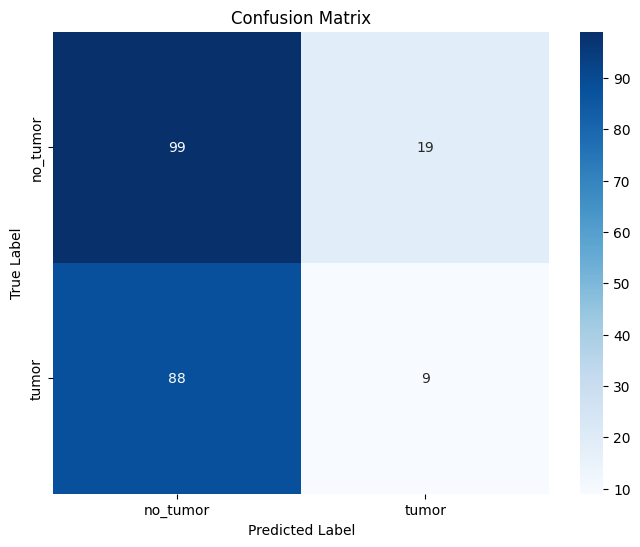

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


In [38]:
print('Classification Report:')
print(report)


Classification Report:
              precision    recall  f1-score   support

    no_tumor       0.53      0.84      0.65       118
       tumor       0.32      0.09      0.14        97

    accuracy                           0.50       215
   macro avg       0.43      0.47      0.40       215
weighted avg       0.44      0.50      0.42       215



In [39]:
torch.save(model.state_dict(), 'densenet_model.pth')


In [40]:
# Initialize the model architecture
model = models.densenet121(pretrained=False)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, NUM_CLASSES)
model = model.to(device)

# Load the saved weights
model.load_state_dict(torch.load('densenet_model.pth'))


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\0871\AppData\Local\Temp\ipykernel_15696\368822950.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value

<All keys matched successfully>

# prediction densenet

Using device: cpu


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\0871\AppData\Local\Temp\ipykernel_16480\4203976559.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default val

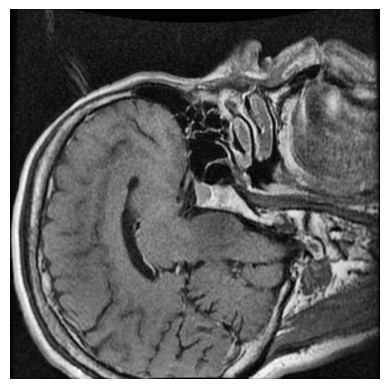

Predicted class: no_tumor
Probabilities:
  no_tumor: 0.6142
  tumor: 0.3858


In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Define the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

# Number of classes
NUM_CLASSES = 2  # 'no_tumor' and 'tumor'

# Load the model architecture
model = models.densenet121(pretrained=False)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, NUM_CLASSES)
model = model.to(device)

# Load the saved model weights
model.load_state_dict(torch.load('densenet_model.pth', map_location=device))
model.eval()  # Set model to evaluation mode

# Define the image transformations
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # Mean for ImageNet
                         [0.229, 0.224, 0.225])  # Std for ImageNet
])

# Load the image
image_path = r'data\valid\tumor\1804_jpg.rf.04c4825489fc2cc5d452b6bb1bd3acca.jpg'  # Replace with the path to your image
image = Image.open(image_path).convert('RGB')

# Display the image
plt.imshow(image)
plt.axis('off')
plt.show()

# Preprocess the image
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)  # Create a mini-batch as expected by the model

# Move the input to the appropriate device
input_batch = input_batch.to(device)

# Make sure to disable gradient calculation for inference
with torch.no_grad():
    output = model(input_batch)
    probabilities = nn.functional.softmax(output[0], dim=0)

# Get the predicted class
_, predicted_idx = torch.max(output, 1)
predicted_class = predicted_idx.item()

# Define the class names
class_names = ['no_tumor', 'tumor']  # Ensure this matches your dataset's class names

# Get the predicted class label
predicted_label = class_names[predicted_class]

# Print the prediction
print(f'Predicted class: {predicted_label}')
print('Probabilities:')
for idx, (classname, probability) in enumerate(zip(class_names, probabilities)):
    print(f'  {classname}: {probability.item():.4f}')



# Prediction Mobilenet

In [47]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt


In [48]:
# Define the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

# Number of classes
NUM_CLASSES = 2  # 'no_tumor' and 'tumor'

# Load the model architecture
model = models.mobilenet_v2(pretrained=False)
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_ftrs, NUM_CLASSES)
)
model = model.to(device)

# Load the saved model weights
model.load_state_dict(torch.load('mobilenet_model.pth', map_location=device))
model.eval()  # Set model to evaluation mode


Using device: cpu


C:\Users\0871\AppData\Local\Temp\ipykernel_15696\2033929782.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('mobilenet_model.pth', map_

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [49]:
# Define the image transformations
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # Mean for ImageNet
                         [0.229, 0.224, 0.225])  # Std for ImageNet
])


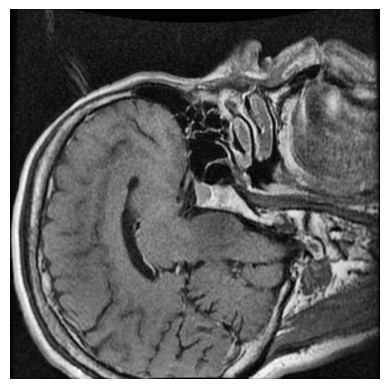

In [62]:
# Load the image
image_path = r'data\valid\tumor\1804_jpg.rf.04c4825489fc2cc5d452b6bb1bd3acca.jpg'  # Replace with the path to your image
image = Image.open(image_path).convert('RGB')

# Display the image
plt.imshow(image)
plt.axis('off')
plt.show()

# Preprocess the image
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)  # Create a mini-batch as expected by the model

# Move the input to the appropriate device
input_batch = input_batch.to(device)


In [63]:
# Make sure to disable gradient calculation for inference
with torch.no_grad():
    output = model(input_batch)
    probabilities = nn.functional.softmax(output[0], dim=0)

# Get the predicted class
_, predicted_idx = torch.max(output, 1)
predicted_class = predicted_idx.item()


In [64]:
# Define the class names
class_names = ['no_tumor', 'tumor']  # Ensure this matches your dataset's class names

# Get the predicted class label
predicted_label = class_names[predicted_class]

# Print the prediction
print(f'Predicted class: {predicted_label}')
print('Probabilities:')
for idx, (classname, probability) in enumerate(zip(class_names, probabilities)):
    print(f'  {classname}: {probability.item():.4f}')


Predicted class: no_tumor
Probabilities:
  no_tumor: 0.6142
  tumor: 0.3858


In [3]:
# torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import transforms
import torch.optim as optim
# utils
import os
from glob import glob
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix


In [4]:
import torch
from glob import glob
import os
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import random
from sklearn.model_selection import train_test_split
from torchvision import transforms

# Global variables
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset_path = "data"  # Update the dataset path to point to the root folder
image_size = (224, 224)
num_classes = 2

# Define paths for train, validation, and test datasets
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "valid")
test_dir = os.path.join(dataset_path, "test")

# Data augmentation for training, resizing for validation and testing
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom dataset class
class CustomDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_paths = glob(os.path.join(self.folder_path, '*', '*.jpg'))
        self.labels = [self.get_label(path) for path in self.image_paths]
        self.labels_to_index = {label: index for index, label in enumerate(list(set(self.labels)))}

    def __getitem__(self, index):
        img_path = self.image_paths[index]
        img = Image.open(img_path).convert('RGB')
        label = self.labels[index]
        label_index = self.labels_to_index[label]

        if self.transform:
            img = self.transform(img)

        return img, label_index

    def __len__(self):
        return len(self.image_paths)

    def get_label(self, path):
        # Get folder name as label (assumes directory name is the label)
        return os.path.basename(os.path.dirname(path))

# Load datasets
train_dataset = CustomDataset(train_dir, transform=train_transform)
val_dataset = CustomDataset(val_dir, transform=test_transform)
test_dataset = CustomDataset(test_dir, transform=test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check device and dataset sizes
print(device)
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Testing set size: {len(test_dataset)}")


cpu
Training set size: 1502
Validation set size: 429
Testing set size: 215


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss: 0.1634, Train Acc: 93.34%, Val Loss: 0.0627, Val Acc: 97.67%
Epoch 2: Train Loss: 0.0630, Train Acc: 98.14%, Val Loss: 0.1148, Val Acc: 95.34%
Epoch 3: Train Loss: 0.0681, Train Acc: 98.14%, Val Loss: 0.0284, Val Acc: 99.53%
Epoch 4: Train Loss: 0.0456, Train Acc: 98.54%, Val Loss: 0.0149, Val Acc: 99.77%
Epoch 5: Train Loss: 0.0291, Train Acc: 98.93%, Val Loss: 0.0254, Val Acc: 99.07%
Epoch 6: Train Loss: 0.0209, Train Acc: 99.33%, Val Loss: 0.0197, Val Acc: 99.30%
Epoch 7: Train Loss: 0.0299, Train Acc: 98.93%, Val Loss: 0.0356, Val Acc: 99.07%
Epoch 8: Train Loss: 0.0207, Train Acc: 99.47%, Val Loss: 0.0286, Val Acc: 99.30%
Epoch 9: Train Loss: 0.0204, Train Acc: 99.33%, Val Loss: 0.0194, Val Acc: 99.53%
Epoch 10: Train Loss: 0.0176, Train Acc: 99.40%, Val Loss: 0.0176, Val Acc: 99.30%


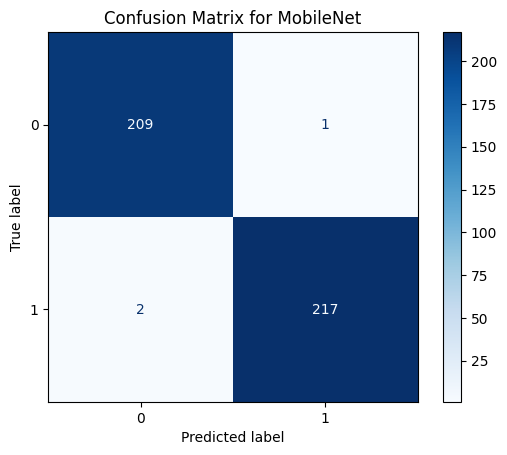

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       210
           1       1.00      0.99      0.99       219

    accuracy                           0.99       429
   macro avg       0.99      0.99      0.99       429
weighted avg       0.99      0.99      0.99       429



In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# Model definition
class MobileNetModel(nn.Module):
    def __init__(self, num_classes):
        super(MobileNetModel, self).__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier[1] = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.mobilenet(x)

# Initialize the model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetModel(num_classes=2).to(device)  # Set num_classes appropriately
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)

def train_epoch():
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch in train_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_predictions += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

def eval_model(loader):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in loader:
            data = batch[0].to(device)
            labels = batch[1].to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_predictions += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

# Main training loop
best_score = float("inf")
n_epochs = 10
tolerance = 0

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch()
    val_loss, val_acc = eval_model(val_loader)

    if val_loss < best_score:
        best_score = val_loss
        torch.save(model.state_dict(), "mobilenet.pt")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

# Generate predictions and true labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in val_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        outputs = model(data)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for MobileNet")
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds))


In [6]:
import torch
from torchvision import transforms
from PIL import Image
import os

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image transformations
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the model class (same as the one used during training)
class MobileNetModel(nn.Module):
    def __init__(self, num_classes):
        super(MobileNetModel, self).__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier[1] = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.mobilenet(x)

# Load the trained model
model = MobileNetModel(num_classes=2)
model.load_state_dict(torch.load("mobilenet.pt"))
model = model.to(device)
model.eval()

def predict_image(image_path):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = image_transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    # Perform the prediction
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)

    return predicted.item()

# Helper function to map the prediction to label
def map_prediction_to_label(prediction):
    label_mapping = {0: "no tumor", 1: "tumor"}
    return label_mapping.get(prediction, "Unknown")

# Example usage
image_path = r"data\train\no_tumor\290_jpg.rf.7a25c3629378201e2aa27e639ac065fc.jpg"
prediction = predict_image(image_path)
predicted_label = map_prediction_to_label(prediction)

print(f"The predicted label for the image is: {predicted_label}")


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\0871\AppData\Local\Temp\ipykernel_16480\3258140997.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https:/

The predicted label for the image is: no tumor


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss: 0.1277, Train Acc: 95.27%, Val Loss: 0.0718, Val Acc: 98.14%
Epoch 2: Train Loss: 0.0591, Train Acc: 98.54%, Val Loss: 0.0947, Val Acc: 96.27%
Epoch 3: Train Loss: 0.0389, Train Acc: 98.80%, Val Loss: 0.1151, Val Acc: 96.97%
Epoch 4: Train Loss: 0.0265, Train Acc: 99.13%, Val Loss: 0.0551, Val Acc: 98.83%
Epoch 5: Train Loss: 0.0285, Train Acc: 99.20%, Val Loss: 0.0570, Val Acc: 98.14%


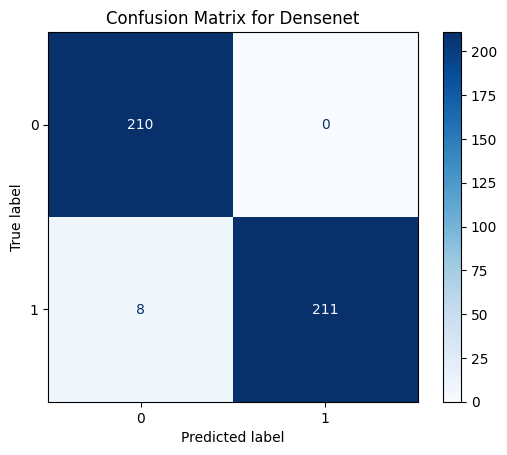

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       210
           1       1.00      0.96      0.98       219

    accuracy                           0.98       429
   macro avg       0.98      0.98      0.98       429
weighted avg       0.98      0.98      0.98       429



In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Loaders as previously defined
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model definition
class DenseNetModel(nn.Module):
    def __init__(self, num_classes):
        super(DenseNetModel, self).__init__()
        self.densenet = models.densenet121(pretrained=True)  # Using DenseNet-121
        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(num_features, num_classes)  # Replace the classifier with a new one

    def forward(self, x):
        return self.densenet(x)

# Initialize the model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNetModel(num_classes=2).to(device)  # Adjust num_classes accordingly
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)

def train_epoch():
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch in train_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_predictions += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

def eval_model(loader):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in loader:
            data = batch[0].to(device)
            labels = batch[1].to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_predictions += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

# Main training loop
best_score = float("inf")
n_epochs = 5
tolerance = 0

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch()
    val_loss, val_acc = eval_model(val_loader)

    if val_loss < best_score:
        best_score = val_loss
        torch.save(model.state_dict(), "densenet.pt")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

# Generate predictions and true labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in val_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        outputs = model(data)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Densenet")
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds))


In [8]:
import torch
from torchvision import transforms
from PIL import Image
import os

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image transformations
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Model definition
class DenseNetModel(nn.Module):
    def __init__(self, num_classes):
        super(DenseNetModel, self).__init__()
        self.densenet = models.densenet121(pretrained=True)  # Using DenseNet-121
        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(num_features, num_classes)  # Replace the classifier with a new one

    def forward(self, x):
        return self.densenet(x)

# Load the trained model
model = DenseNetModel(num_classes=2)
model.load_state_dict(torch.load("densenet.pt"))
model = model.to(device)
model.eval()

def predict_image(image_path):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = image_transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    # Perform the prediction
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)

    return predicted.item()

# Helper function to map the prediction to label
def map_prediction_to_label(prediction):
    label_mapping = {0: "no tumor", 1: "tumor"}
    return label_mapping.get(prediction, "Unknown")

# Example usage
image_path = r"data\train\no_tumor\2921_jpg.rf.3b952f91f27a6248091e7601c22323ad.jpg"  # Replace with your image path
prediction = predict_image(image_path)
predicted_label = map_prediction_to_label(prediction)

print(f"The predicted label for the image is: {predicted_label}")


C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\0871\AppData\Roaming\Python\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\0871\AppData\Local\Temp\ipykernel_16480\2871233047.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://g

The predicted label for the image is: no tumor
